In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="NidhiSilmana@123",
    database="student_db"
)

print("Connected Successfully")
cursor = conn.cursor()
print("Connected to Database")

Connected Successfully
Connected to Database


In [3]:
query = "SELECT * FROM Students"
df_students = pd.read_sql(query, conn)
df_students

C:\Users\sachi\AppData\Local\Temp\ipykernel_19920\3636408484.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_students = pd.read_sql(query, conn)


,student_id,name,age,course,city
0,1,Nidhi,21,BCA,Dehradun
1,2,Rahul,22,BCA,Delhi
2,3,Aman,20,BCA,Mumbai
3,4,Priya,21,BCA,Noida
4,5,Karan,23,BCA,Pune
5,6,Simran,22,BBA,Chandigarh
6,7,Rohit,21,BBA,Delhi
7,8,Anjali,20,BBA,Jaipur
8,9,Vikas,24,BBA,Lucknow
9,10,Neha,21,BBA,Dehradun


C:\Users\sachi\AppData\Local\Temp\ipykernel_19920\304113510.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top = pd.read_sql(query, conn)


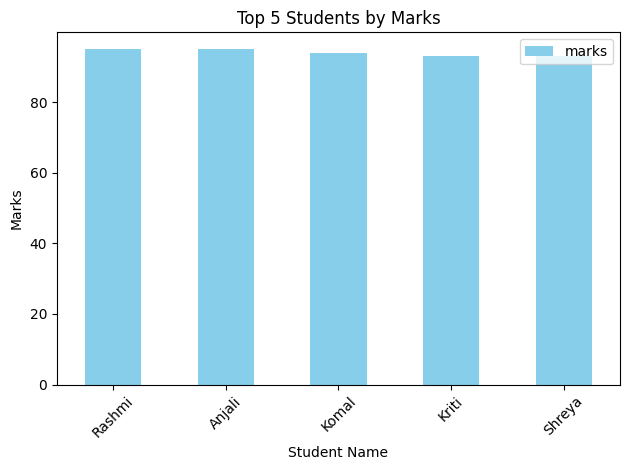

In [4]:
query = """
SELECT s.name, c.course_name, m.marks
FROM Students s
JOIN Marks m ON s.student_id = m.student_id
JOIN Courses c ON m.course_id = c.course_id
ORDER BY m.marks DESC
LIMIT 5
"""
df_top = pd.read_sql(query, conn)
df_top.plot(kind='bar', x='name', y='marks', color='skyblue')
plt.title('Top 5 Students by Marks')
plt.xlabel('Student Name')
plt.ylabel('Marks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\sachi\AppData\Local\Temp\ipykernel_19920\572866513.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_low = pd.read_sql(query, conn)


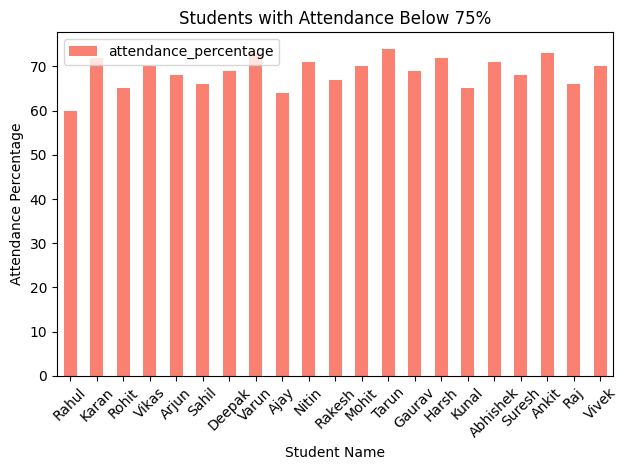

In [5]:
query = """
SELECT s.name, a.attendance_percentage
FROM Students s
JOIN Attendance a ON s.student_id = a.student_id
WHERE a.attendance_percentage < 75
"""
df_low = pd.read_sql(query, conn)
df_low.plot(kind='bar', x='name', y='attendance_percentage', color='salmon')
plt.title('Students with Attendance Below 75%') 
plt.xlabel('Student Name')
plt.ylabel('Attendance Percentage')         
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\sachi\AppData\Local\Temp\ipykernel_19920\3255952771.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_avg = pd.read_sql(query, conn)


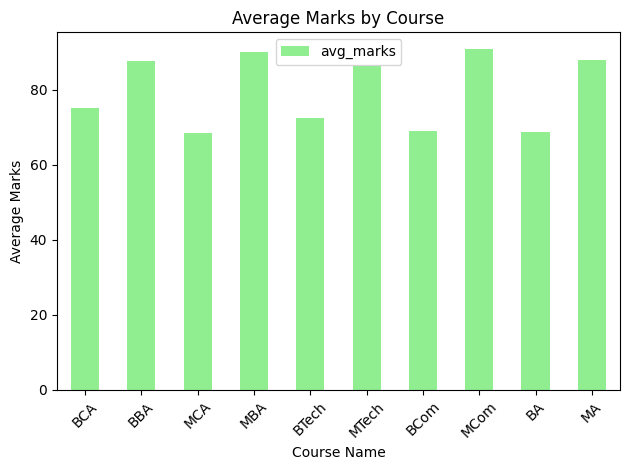

In [6]:
query = """
SELECT c.course_name, AVG(m.marks) AS avg_marks
FROM Marks m
JOIN Courses c ON m.course_id = c.course_id
GROUP BY c.course_name
"""
df_avg = pd.read_sql(query, conn)
df_avg.plot(kind='bar', x='course_name', y='avg_marks', color='lightgreen')
plt.title('Average Marks by Course')    
plt.xlabel('Course Name')
plt.ylabel('Average Marks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

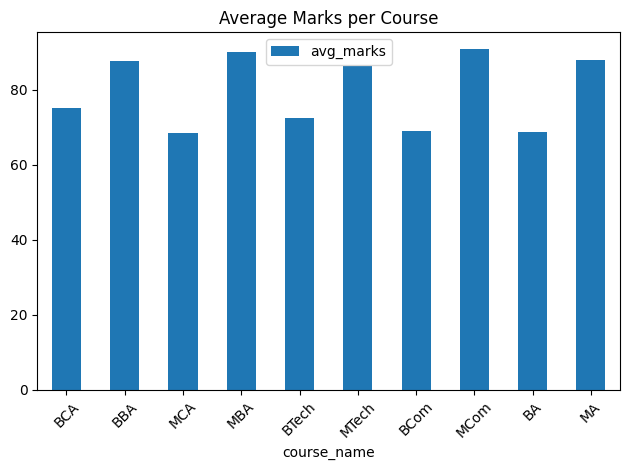

In [7]:
plt.figure()
df_avg.plot(x='course_name', y='avg_marks', kind='bar')
plt.title("Average Marks per Course")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
conn.close()
print("Connection Closed")

Connection Closed
